In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
df = pd.read_csv('/content/signal_metrics.csv')
# df = pd.read_csv('../data/raw/signal_metrics.csv')

# Data Throughput Prediction

## 1. Dataset Overview

The dataset contains network-related measurements collected from different localities and network types.

The main objective of this project is to build machine learning regression models that can predict **Data Throughput (Mbps)** based on the available network and signal-related features.

### Dataset Dimensions

The dataset contains **16,829 observations and 12 columns**.

The target variable is:

- **Data Throughput (Mbps)**

The remaining columns represent network, geographical, signal, measurement, and latency-related information.

In [5]:
df.shape

(16829, 12)

### Finding

The dataset contains 16,829 observations and 12 columns, providing a sufficient number of samples for training and comparing multiple regression models.

## 2. Initial Data Inspection

We inspected the first few rows of the dataset to understand the structure, feature names, and the type of information contained in each observation.

In [6]:
df.head()

,Timestamp,Locality,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),Network Type,BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
0,2023-05-05 12:50:40.000000,Anisabad,25.599109,85.137355,-84.274113,0.0,1.863890,129.122914,3G,0.000000,0.000000,0.000000
1,2023-05-05 12:53:47.210173,Fraser Road,25.433286,85.070053,-97.653121,0.0,5.132296,54.883606,4G,-95.810791,-105.452359,-99.920892
2,2023-05-05 12:56:54.420346,Boring Canal Road,25.498809,85.211371,-87.046134,0.0,1.176985,119.598286,LTE,-91.593861,-95.419482,-87.714070
3,2023-05-05 13:00:01.630519,Danapur,25.735138,85.208400,-94.143159,0.0,68.596932,46.598387,5G,-90.642773,-101.895905,-96.570698
4,2023-05-05 13:03:08.840692,Phulwari Sharif,25.538556,85.159860,-94.564765,0.0,38.292038,30.342828,5G,-90.489100,-103.318304,-95.102467


### Finding

The dataset contains timestamp, geographical, signal, latency, network type, and measurement-related features.

The target variable is **Data Throughput (Mbps)**, which is a continuous numerical variable and therefore makes this a regression problem.

## 3. Data Types and Missing Values

We examined the data types and the number of non-null values in each column.

This step helps identify numerical and categorical variables and checks whether missing values need to be handled before further analysis.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16829 entries, 0 to 16828
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     16829 non-null  object 
 1   Locality                      16829 non-null  object 
 2   Latitude                      16829 non-null  float64
 3   Longitude                     16829 non-null  float64
 4   Signal Strength (dBm)         16829 non-null  float64
 5   Signal Quality (%)            16829 non-null  float64
 6   Data Throughput (Mbps)        16829 non-null  float64
 7   Latency (ms)                  16829 non-null  float64
 8   Network Type                  16829 non-null  object 
 9   BB60C Measurement (dBm)       16829 non-null  float64
 10  srsRAN Measurement (dBm)      16829 non-null  float64
 11  BladeRFxA9 Measurement (dBm)  16829 non-null  float64
dtypes: float64(9), object(3)
memory usage: 1.5+ MB


In [8]:
df.describe()

,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
count,16829.000000,16829.000000,16829.000000,16829.0,16829.000000,16829.000000,16829.000000,16829.000000,16829.000000
mean,25.594796,85.137314,-90.072484,0.0,16.182856,101.313624,-68.820150,-74.439562,-68.819930
std,0.089881,0.090095,5.399368,0.0,25.702734,56.010418,40.046739,43.215204,39.996934
min,25.414575,84.957936,-116.942267,0.0,1.000423,10.019527,-115.667514,-124.652054,-119.207545
25%,25.522858,85.064124,-93.615962,0.0,2.001749,50.320775,-94.021959,-101.249987,-93.749032
50%,25.595383,85.138149,-89.665566,0.0,2.997175,100.264318,-89.126942,-96.838442,-89.282746
75%,25.667620,85.209504,-86.145491,0.0,9.956314,149.951112,0.000000,0.000000,0.000000
max,25.773648,85.316994,-74.644848,0.0,99.985831,199.991081,0.000000,0.000000,0.000000


In [9]:
df.isna().sum()

,0
Timestamp,0
Locality,0
Latitude,0
Longitude,0
Signal Strength (dBm),0
Signal Quality (%),0
Data Throughput (Mbps),0
Latency (ms),0
Network Type,0
BB60C Measurement (dBm),0


### Finding

The dataset contains:

- 9 numerical columns.
- 3 object-type columns.
- No missing values were found in any column.

Therefore, no missing-value imputation or removal of observations is required at this stage.

## 4. Duplicate Records

We checked the dataset for duplicated observations to ensure that repeated records do not bias the analysis or model training.

In [10]:
df.duplicated().sum()

np.int64(0)

### Finding

No duplicate rows were found in the dataset.

Therefore, no duplicate records need to be removed.

## 5. Categorical Feature Analysis

We examined the categorical features to understand their unique categories and their distribution within the dataset.

In [11]:
df['Network Type'].value_counts()

,count
Network Type,
LTE,4224
4G,4219
3G,4208
5G,4178


### Finding

The dataset contains four network types:

- 3G: 4,208 observations
- 4G: 4,219 observations
- LTE: 4,224 observations
- 5G: 4,178 observations

The distribution is relatively balanced across the four network types, with no category being significantly underrepresented.

In [12]:
df['Locality'].nunique()

20

### Finding

The dataset contains **20 unique localities**.

This feature may provide useful geographical information for predicting data throughput and will be considered during feature preprocessing.

## 6. Target Variable Analysis

Before training regression models, we analyzed the distribution of the target variable, **Data Throughput (Mbps)**.

Understanding the target distribution helps identify skewness, unusual values, and potential issues that may affect model performance.

In [14]:
df['Data Throughput (Mbps)'].describe()

,Data Throughput (Mbps)
count,16829.000000
mean,16.182856
std,25.702734
min,1.000423
25%,2.001749
50%,2.997175
75%,9.956314
max,99.985831


### Finding

The target variable has the following characteristics:

- Mean: approximately 16.18 Mbps
- Median: approximately 3.00 Mbps
- Minimum: approximately 1.00 Mbps
- Maximum: approximately 99.99 Mbps
- Standard deviation: approximately 25.70 Mbps

The large difference between the mean and median indicates that the target distribution is strongly right-skewed.

## 7. Target Distribution Analysis

A histogram was used to visualize the distribution of **Data Throughput (Mbps)** and better understand how the target values are distributed.

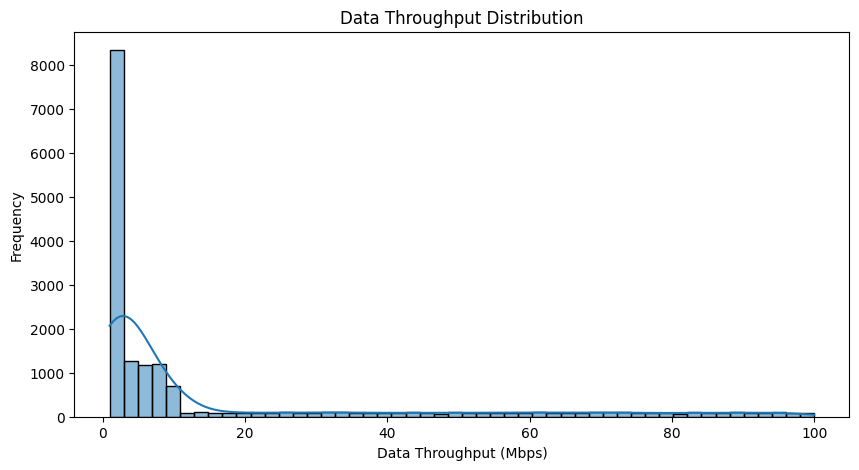

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Data Throughput (Mbps)'], bins = 50, kde = True)
plt.title('Data Throughput Distribution')
plt.xlabel('Data Throughput (Mbps)')
plt.ylabel('Frequency')

plt.show()

In [18]:
df['Data Throughput (Mbps)'].value_counts(bins=10).sort_index()

,count
"(0.9, 10.899]",12697
"(10.899, 20.798]",478
"(20.798, 30.696]",454
"(30.696, 40.595]",477
"(40.595, 50.493]",437
"(50.493, 60.392]",455
"(60.392, 70.29]",480
"(70.29, 80.189]",455
"(80.189, 90.087]",439
"(90.087, 99.986]",457


### Finding

The target distribution is highly right-skewed.

Approximately **12,697 out of 16,829 observations (75.5%)** fall within the range of approximately **0.9 to 10.9 Mbps**.

However, the remaining observations are distributed across the higher throughput ranges up to approximately 100 Mbps.

Therefore, the higher throughput values should not be automatically treated as outliers or removed, as they represent a substantial portion of the dataset.

## 8. Numerical Features Summary

We used descriptive statistics to examine the central tendency, spread, and range of the numerical variables.

This helps identify potential issues such as constant features, unusual ranges, or suspicious values before performing further preprocessing.

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,16829.0,25.594796,0.089881,25.414575,25.522858,25.595383,25.667620,25.773648
Longitude,16829.0,85.137314,0.090095,84.957936,85.064124,85.138149,85.209504,85.316994
Signal Strength (dBm),16829.0,-90.072484,5.399368,-116.942267,-93.615962,-89.665566,-86.145491,-74.644848
Signal Quality (%),16829.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Data Throughput (Mbps),16829.0,16.182856,25.702734,1.000423,2.001749,2.997175,9.956314,99.985831
Latency (ms),16829.0,101.313624,56.010418,10.019527,50.320775,100.264318,149.951112,199.991081
BB60C Measurement (dBm),16829.0,-68.820150,40.046739,-115.667514,-94.021959,-89.126942,0.000000,0.000000
srsRAN Measurement (dBm),16829.0,-74.439562,43.215204,-124.652054,-101.249987,-96.838442,0.000000,0.000000
BladeRFxA9 Measurement (dBm),16829.0,-68.819930,39.996934,-119.207545,-93.749032,-89.282746,0.000000,0.000000


### Finding

The `Signal Quality (%)` feature has zero variance:

- Mean = 0
- Standard deviation = 0
- Minimum = 0
- Maximum = 0

This indicates that all observations have the same value for this feature, meaning it provides no useful information for the regression models.

This feature will therefore be considered for removal during the feature preprocessing stage.

## 9. Feature Relationships with the Target

To understand which numerical features may be useful for predicting **Data Throughput (Mbps)**, we examined the correlation between the numerical features and the target variable.

Correlation measures the strength and direction of a linear relationship between two numerical variables.

The correlation coefficient ranges from **-1 to +1**:

* Values close to **+1** indicate a strong positive relationship.
* Values close to **-1** indicate a strong negative relationship.
* Values close to **0** indicate a weak or no linear relationship.


In [20]:
correlation_with_target = (
    df.select_dtypes(include='number')
      .corr()['Data Throughput (Mbps)']
      .sort_values(ascending=False)
)

correlation_with_target

,Data Throughput (Mbps)
Data Throughput (Mbps),1.000000
Longitude,0.003507
Latitude,0.000526
srsRAN Measurement (dBm),-0.355608
BB60C Measurement (dBm),-0.358088
BladeRFxA9 Measurement (dBm),-0.358540
Signal Strength (dBm),-0.483769
Latency (ms),-0.668173
Signal Quality (%),NaN


### Finding

The correlation analysis shows that **Latency (ms)** has the strongest linear relationship with **Data Throughput (Mbps)**, with a correlation coefficient of approximately **-0.67**.

**Signal Strength (dBm)** also shows a moderate negative correlation of approximately **-0.48**.

The three measurement features show moderate negative correlations with the target, with values around **-0.36**.

In contrast, **Latitude** and **Longitude** have correlations very close to zero, indicating no meaningful linear relationship with the target.

The **Signal Quality (%)** feature returns `NaN` because it has zero variance, as all of its values are identical.


In [21]:
df['Signal Quality (%)'].nunique()

1

### Finding

The `Signal Quality (%)` feature contains only one unique value across all observations.

Since the feature has zero variance and the same value for every observation, it provides no predictive information for the regression models.

### Decision

The `Signal Quality (%)` feature will be removed during the preprocessing stage.


## 10. Network Type and Data Throughput

We analyzed the relationship between **Network Type** and **Data Throughput (Mbps)** by comparing the target distribution across different network types.

This helps determine whether network technology is associated with differences in achievable data throughput.


In [27]:
df.groupby('Network Type')['Data Throughput (Mbps)'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).sort_values('mean', ascending = False)

,count,mean,median,std,min,max
Network Type,,,,,,
5G,4178,54.584263,54.694480,26.093613,10.015757,99.985831
4G,4219,6.499208,6.505610,2.032076,3.000707,9.999703
3G,4208,2.006362,2.009530,0.581736,1.000423,2.999602
LTE,4224,1.994625,1.997974,0.581030,1.000825,2.999323


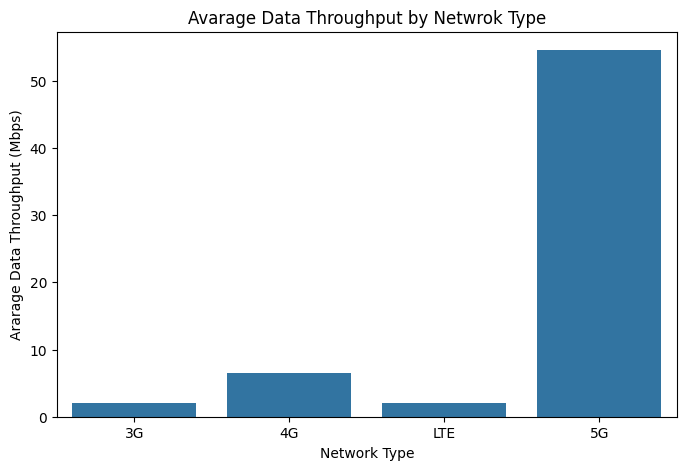

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data = df,
    x = 'Network Type',
    y = 'Data Throughput (Mbps)',
    estimator = 'mean',
    errorbar = None
)

plt.title('Avarage Data Throughput by Netwrok Type')
plt.xlabel('Network Type')
plt.ylabel('Ararage Data Throughput (Mbps)')

plt.show()

### Finding

The analysis shows a strong difference in **Data Throughput (Mbps)** across network types.

The average throughput is approximately:

* **5G:** 54.58 Mbps
* **4G:** 6.50 Mbps
* **3G:** 2.01 Mbps
* **LTE:** 1.99 Mbps

The throughput ranges also differ substantially between network types. The 5G observations cover much higher throughput values, while 3G and LTE observations remain within a much lower range.

### Conclusion

**Network Type appears to be an important feature for predicting Data Throughput (Mbps)** and should be retained during preprocessing and model training.


## 11. Locality and Data Throughput

We analyzed the relationship between **Locality** and **Data Throughput (Mbps)** to determine whether geographical location is associated with differences in network performance.

For each locality, we calculated the number of observations, mean throughput, median throughput, and standard deviation.


In [29]:
locality_stats = (
    df.groupby('Locality')['Data Throughput (Mbps)']
      .agg(['count', 'mean', 'median', 'std'])
      .sort_values('mean', ascending=False)
)
locality_stats

,count,mean,median,std
Locality,,,,
Rajendra Nagar,817,17.660316,3.233219,27.061990
Pataliputra,850,17.339332,3.283682,26.528938
Kidwaipuri,873,16.910623,3.244145,25.816433
Gandhi Maidan,885,16.743540,3.320702,25.828600
Boring Road,851,16.617689,3.321342,25.614931
Anisabad,830,16.573477,3.164646,26.348689
Gardanibagh,846,16.572024,3.136115,26.238690
Anandpuri,799,16.547728,2.933307,26.737148
Kumhrar,840,16.537564,2.937498,25.823173


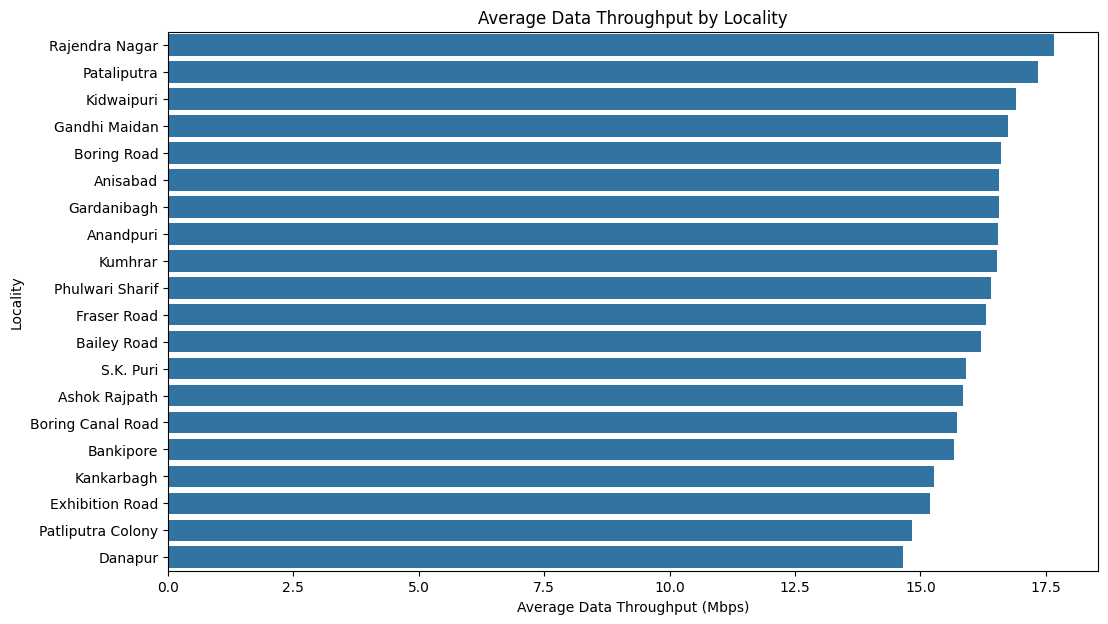

In [31]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data = locality_stats.reset_index(),
    x = 'mean',
    y = 'Locality',
    errorbar=None
)

plt.title('Average Data Throughput by Locality')
plt.xlabel('Average Data Throughput (Mbps)')
plt.ylabel('Locality')

plt.show()

### Finding

The average data throughput varies across different localities.

The highest average throughput was observed in **Rajendra Nagar (17.66 Mbps)**, while the lowest was observed in **Danapur (14.65 Mbps)**.

Although there are differences between localities, the variation is relatively smaller than the differences observed between network types.

The median throughput remains close to 3 Mbps across most localities, while the mean is considerably higher. This is consistent with the strong right-skewed distribution observed in the target variable.

### Conclusion

**Locality may provide useful predictive information** about Data Throughput and will therefore be retained as a categorical feature for model training.


## 12. Latency vs Data Throughput

We visualized the relationship between **Latency (ms)** and **Data Throughput (Mbps)** using a scatter plot.

This relationship was selected because latency had the strongest correlation with the target among the numerical features, with a correlation coefficient of approximately **-0.67**.


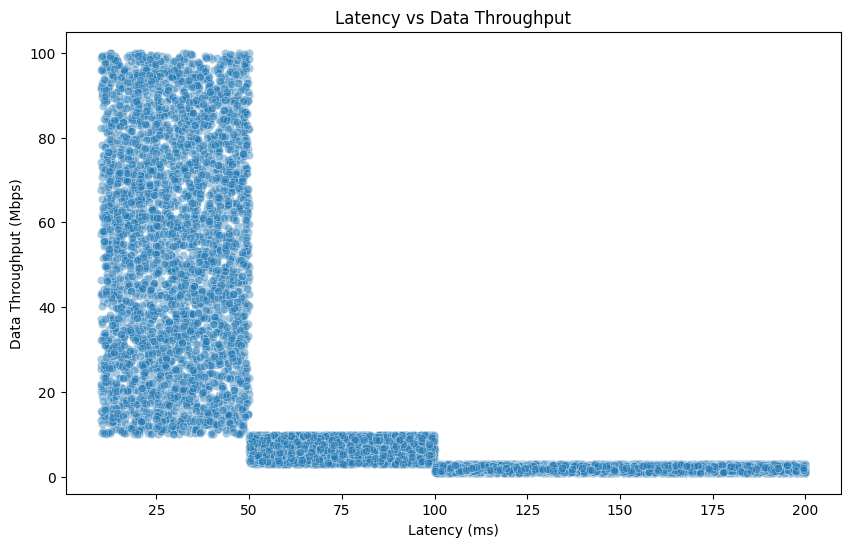

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = df,
    x = 'Latency (ms)',
    y = 'Data Throughput (Mbps)',
    alpha = 0.4
)

plt.title('Latency vs Data Throughput')
plt.xlabel('Latency (ms)')
plt.ylabel('Data Throughput (Mbps)')

plt.show()

### Finding

The scatter plot reveals a strong negative relationship between **Latency (ms)** and **Data Throughput (Mbps)**.

The observations form distinct performance regions:

* **Low latency (approximately 10–50 ms):** Throughput values are distributed across a wide range, including values from approximately 10 Mbps to 100 Mbps.
* **Medium latency (approximately 50–100 ms):** Throughput is concentrated in a lower range, approximately between 3 Mbps and 10 Mbps.
* **High latency (approximately 100–200 ms):** Throughput is concentrated at very low values, approximately between 1 Mbps and 3 Mbps.

The step-like pattern suggests the presence of distinct network performance regimes rather than a simple smooth linear relationship.

### Conclusion

Latency is an important feature for predicting Data Throughput. The strong negative correlation and the distinct performance regions indicate that the relationship between latency and throughput is not purely linear.

This observation may be particularly relevant when comparing linear models with non-linear models such as Random Forest and XGBoost.


## 13. Signal Strength vs Data Throughput

We visualized the relationship between **Signal Strength (dBm)** and **Data Throughput (Mbps)** using a scatter plot.

Signal Strength was selected because it has the second strongest linear correlation with the target variable, with a correlation coefficient of approximately **-0.48**.

The visualization helps us understand the direction, strength, and pattern of this relationship.

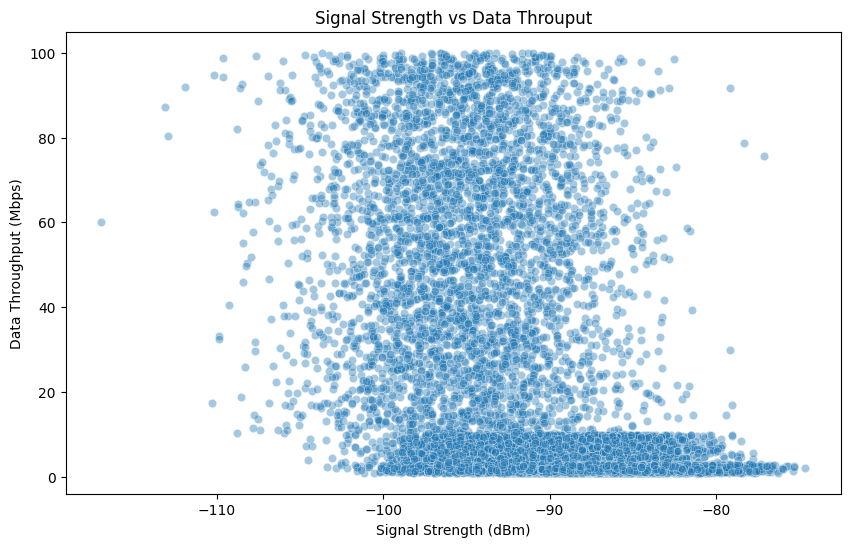

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data = df,
    x = 'Signal Strength (dBm)',
    y = 'Data Throughput (Mbps)',
    alpha = 0.4
)

plt.title('Signal Strength vs Data Throuput')
plt.xlabel('Signal Strength (dBm)')
plt.ylabel('Data Throughput (Mbps)')

plt.show()

### Finding

The scatter plot shows a **moderate negative relationship** between **Signal Strength (dBm)** and **Data Throughput (Mbps)**, consistent with the Pearson correlation coefficient of approximately **-0.48**.

The observations show substantial variation in throughput across the signal strength range. In particular:

* For signal strengths between approximately **-105 and -85 dBm**, throughput values cover a wide range, from very low values to nearly 100 Mbps.
* A dense concentration of observations remains below approximately **10 Mbps** across a relatively wide range of signal strengths.
* At stronger signal levels, the throughput does not consistently increase and some observations remain at very low throughput values.

This indicates that stronger signal strength alone does not guarantee higher data throughput in this dataset.

### Conclusion

**Signal Strength (dBm) provides useful predictive information but is not sufficient by itself to explain Data Throughput (Mbps).**

The wide variation in throughput at similar signal strength levels suggests that other factors, such as **Latency, Network Type, and other network-related measurements**, also contribute to the observed throughput.


## 14. Measurement Features vs Data Throughput

We analyzed the relationships between the three measurement features and **Data Throughput (Mbps)** using scatter plots.

The measurement features are:

- BB60C Measurement (dBm)
- srsRAN Measurement (dBm)
- BladeRFxA9 Measurement (dBm)

These features were selected because they show moderate negative correlations with the target variable.

The visualizations also help investigate the distribution of their values and the presence of zero-valued measurements.

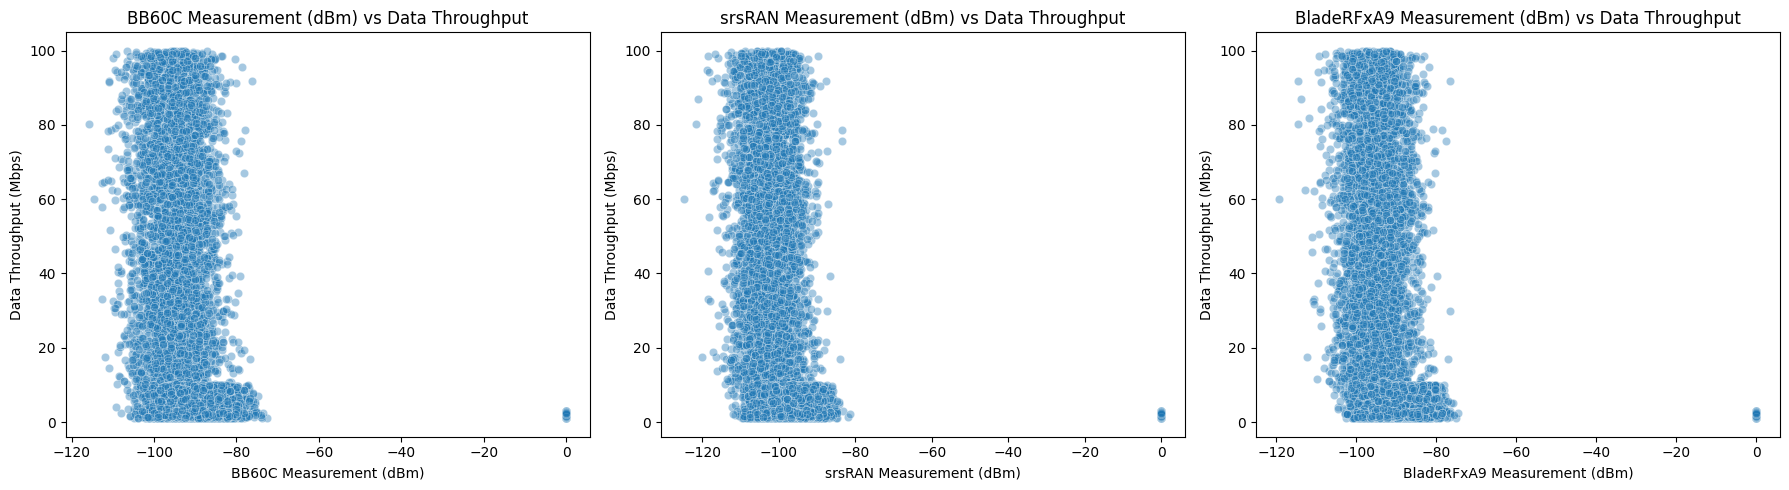

In [39]:
mesurement_features = [
    'BB60C Measurement (dBm)',
    'srsRAN Measurement (dBm)',
    'BladeRFxA9 Measurement (dBm)'
]

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

for ax, feature in zip(axes, mesurement_features):
  sns.scatterplot(
      data = df,
      x = feature,
      y = 'Data Throughput (Mbps)',
      alpha = 0.4,
      ax = ax
  )
  ax.set_title(f'{feature} vs Data Throughput')
  ax.set_xlabel(feature)
  ax.set_ylabel('Data Throughput (Mbps)')

plt.tight_layout()
plt.show()

### Finding

The three measurement features show very similar patterns when compared with **Data Throughput (Mbps)**.

Across **BB60C, srsRAN, and BladeRFxA9**, the measurements cover a similar range, while throughput values vary substantially at similar measurement levels.

A large concentration of observations remains below approximately **10 Mbps**, while higher throughput values are distributed across a relatively wide range of measurement values.

The three features also exhibit similar overall distributions, suggesting that they may provide overlapping information about the network signal measurements.

The presence of zero-valued measurements is also noticeable and requires further investigation before deciding whether these values represent valid measurements or unavailable/default values.

### Conclusion

The measurement features contain potentially useful information, as indicated by their moderate negative correlations with the target. However, their highly similar patterns and the presence of zero-valued measurements require further data-quality investigation before making a final decision about retaining or removing these features.


## 15. Numerical Features Correlation Heatmap

A correlation heatmap was used to visualize the linear relationships between the numerical features in the dataset.

This analysis helps identify strongly correlated features and possible redundant information before the preprocessing stage.

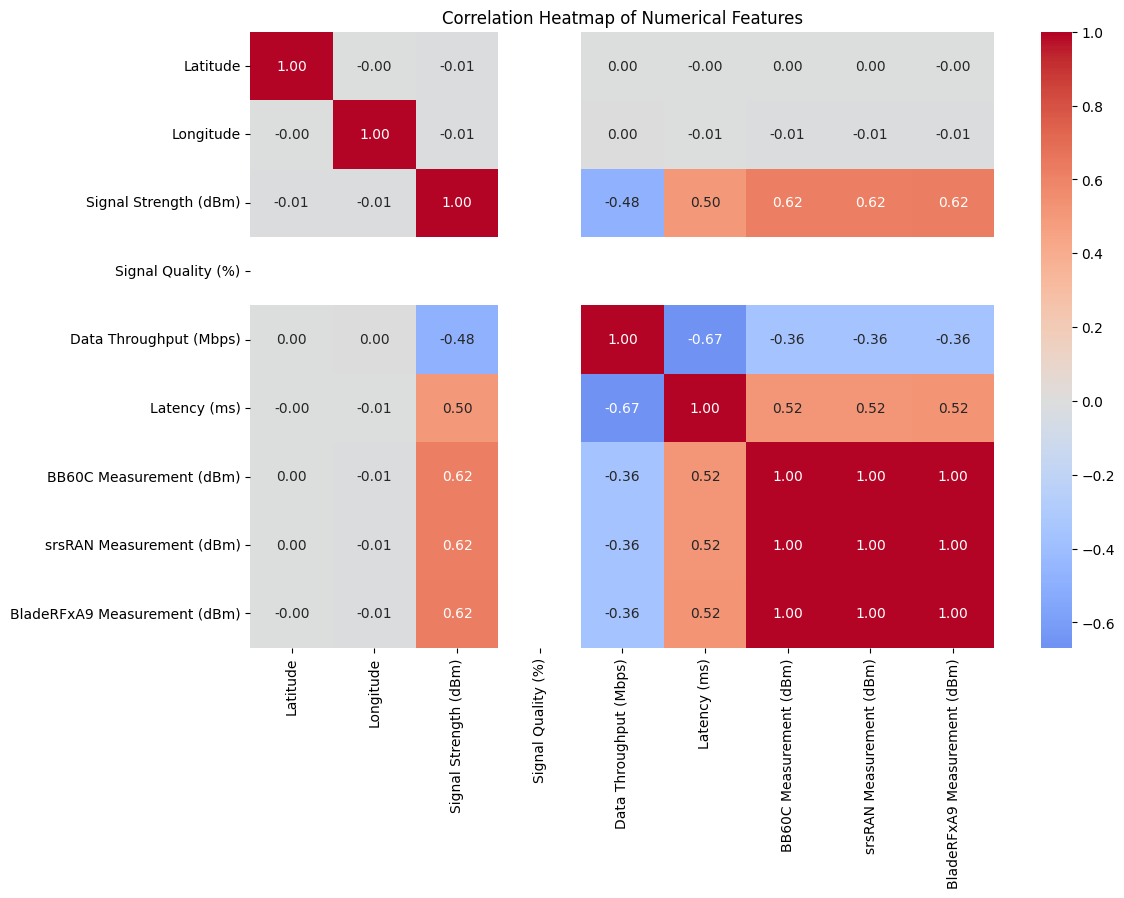

In [40]:
plt.figure(figsize = (12, 8))

correlation_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center = 0
)
plt.title('Correlation Heatmap of Numerical Features')

plt.show()

### Finding

The correlation heatmap reveals several important relationships among the numerical features.

The three measurement features, **BB60C Measurement**, **srsRAN Measurement**, and **BladeRFxA9 Measurement**, show an almost perfect positive correlation with each other (approximately **r = 1.00**). This indicates that they provide highly similar information and may be redundant.

**Latency (ms)** has the strongest linear relationship with **Data Throughput (Mbps)**, with a correlation of approximately **-0.67**.

**Signal Strength (dBm)** also shows a moderate negative correlation with the target (approximately **-0.48**), while the three measurement features show moderate negative correlations of approximately **-0.36**.

Latitude and Longitude have correlations very close to zero with most network performance variables, indicating that they do not show meaningful linear relationships with the target.

The **Signal Quality (%)** feature appears as `NaN` in the correlation matrix because it has zero variance, as all observations contain the same value.

### Decision

The three measurement features will be removed during preprocessing because they are highly redundant with each other and provide overlapping information.

The **Signal Quality (%)** feature will also be removed because it is a constant feature with zero variance.


## 16. Timestamp Analysis

The `Timestamp` feature represents the time at which each network measurement was recorded.

Before deciding whether to use this feature for modeling, we first inspect its format and temporal coverage.

In [41]:
df['Timestamp'].head()

,Timestamp
0,2023-05-05 12:50:40.000000
1,2023-05-05 12:53:47.210173
2,2023-05-05 12:56:54.420346
3,2023-05-05 13:00:01.630519
4,2023-05-05 13:03:08.840692


In [44]:
df['Timestamp'].dtype

dtype('O')

### Timestamp Coverage

We examined the temporal range of the dataset to determine the period covered by the collected observations.

The `Timestamp` column is currently stored as an object, even though its values follow a datetime format.

In [47]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print("Start:", df['Timestamp'].min())
print("End:", df['Timestamp'].max())
print("Duration:", df['Timestamp'].max() - df['Timestamp'].min())

Start: 2023-05-05 12:50:40
End: 2023-06-10 23:56:52.791244
Duration: 36 days 11:06:12.791244


### Throughput Over Time

Since the dataset covers more than one month, we examined how **Data Throughput (Mbps)** changes over time.

This helps determine whether the timestamp contains useful temporal information or whether it can be excluded from the modeling features.

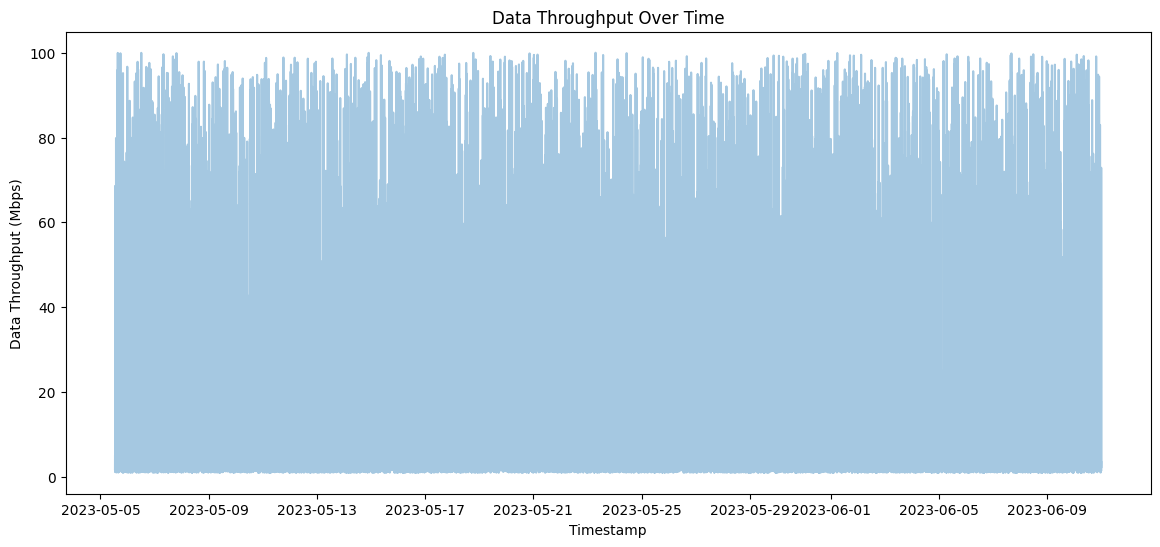

In [48]:
plt.figure(figsize=(14, 6))

plt.plot(
    df['Timestamp'],
    df['Data Throughput (Mbps)'],
    alpha = 0.4
)
plt.title('Data Throughput Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Data Throughput (Mbps)')

plt.show()

### Finding

The time-series analysis shows that **Data Throughput (Mbps)** fluctuates substantially throughout the observation period, but no clear long-term trend, systematic increase or decrease, or obvious seasonal pattern is visible.

The throughput remains within a similar overall range throughout the approximately 36-day collection period, with frequent fluctuations between low values and values close to 100 Mbps.

The analysis therefore does not provide strong evidence that the raw timestamp contains useful predictive information for the target.

### Decision

The `Timestamp` feature will be excluded from the initial modeling features.

This decision avoids introducing temporal features without clear evidence of a meaningful time-dependent pattern. The focus will instead remain on network, signal, geographical, and latency-related features.

## 17. Final Feature Audit

Based on the exploratory data analysis, each feature was reviewed to determine whether it should be retained, removed, or used as the target variable.

The decisions were based on data quality, statistical properties, feature relationships, redundancy, and the observed patterns in the dataset.

### Feature Decisions

| Feature | Decision | Reason |
|---|---|---|
| `Timestamp` | Remove | No clear temporal pattern was observed |
| `Locality` | Keep | May provide useful geographical information |
| `Latitude` | Keep | Potential geographical information |
| `Longitude` | Keep | Potential geographical information |
| `Signal Strength (dBm)` | Keep | Shows a moderate relationship with the target |
| `Signal Quality (%)` | Remove | Constant feature with zero variance |
| `Data Throughput (Mbps)` | Target | Continuous variable to be predicted |
| `Latency (ms)` | Keep | Shows the strongest linear relationship with the target |
| `Network Type` | Keep | Shows substantial differences in throughput across categories |
| `BB60C Measurement (dBm)` | Remove | Highly redundant with the other measurement features |
| `srsRAN Measurement (dBm)` | Remove | Highly redundant with the other measurement features |
| `BladeRFxA9 Measurement (dBm)` | Remove | Highly redundant with the other measurement features |

### EDA Summary

The exploratory analysis identified several important characteristics of the dataset:

- The target variable is strongly right-skewed.
- `Network Type` shows substantial differences in throughput.
- `Latency` has the strongest linear relationship with the target.
- `Signal Strength` provides useful but incomplete predictive information.
- `Locality` shows smaller differences in average throughput but may still provide useful information.
- `Signal Quality (%)` is constant and provides no predictive information.
- The three measurement features are highly redundant with each other.
- No clear temporal pattern was observed in the `Timestamp` analysis.

These findings will guide the preprocessing and feature engineering steps in the next stage.